<a href="https://colab.research.google.com/github/ArshadJafri/knn_usps/blob/main/knn_usps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
import h5py
with h5py.File('/content/sample_data/usps.h5','r') as hf:
  train = hf.get('train')
  X_tr = train.get('data')[:]
  y_tr =train.get('target')[:]
  test = hf.get('test')
  X_te =test.get('data')[:]
  y_te =test.get('target')[:]


In [5]:
X_tr.shape

(7291, 256)

In [6]:
y_tr.shape

(7291,)

In [7]:
X_te.shape

(2007, 256)

In [9]:
y_te.shape

(2007,)

In [12]:
type(X_tr)
X_tr_pd = pd.DataFrame(X_tr)


In [19]:
X_tr[1]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.34999883e-02,
       1.64499998e-01, 9.54999924e-02, 5.64999878e-02, 1.64499998e-01,
       7.35000074e-02, 0.00000000e+00, 0.00000000e+00, 1.13000005e-01,
       4.09999996e-01, 5.26000023e-01, 3.79500002e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.95999980e-01,
       1.00000000e+00, 9.28499997e-01, 8.63499999e-01, 1.00000000e+00,
       9.02500033e-01, 8.06499958e-01, 8.06499958e-01, 9.30000007e-01,
       1.00000000e+00, 1.00000000e+00, 6.98000014e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.26000011e-01,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 9.37500000e-01, 2.14999914e-02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.06999993e-01,
       9.80499983e-01, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
      

In [24]:
len(X_tr[1])

256

In [13]:
X_tr_pd.head()

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.1845,0.9310,0.4165,...,0.6520,0.9115,1.0000,0.7410,0.2630,0.0045,0.0000,0.0000,0.000,0.0
1,0.0,0.0,0.0,0.0935,0.1645,0.0955,0.0565,0.1645,0.0735,0.0000,...,0.1645,0.1645,0.4835,0.8805,0.8810,0.5630,0.4525,0.1645,0.086,0.0
2,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0020,...,0.0000,0.0000,0.0000,0.4455,1.0000,0.4105,0.0000,0.0000,0.000,0.0
3,0.0,0.0,0.0,0.0000,0.0000,0.3635,0.8420,0.9800,0.7250,0.4665,...,0.3410,1.0000,0.7680,0.0065,0.0000,0.0000,0.0000,0.0000,0.000,0.0
4,0.0,0.0,0.0,0.0000,0.0000,0.0360,0.3980,0.8755,0.7330,0.6170,...,0.7330,0.8195,1.0000,1.0000,0.8955,0.7195,0.4005,0.0585,0.000,0.0


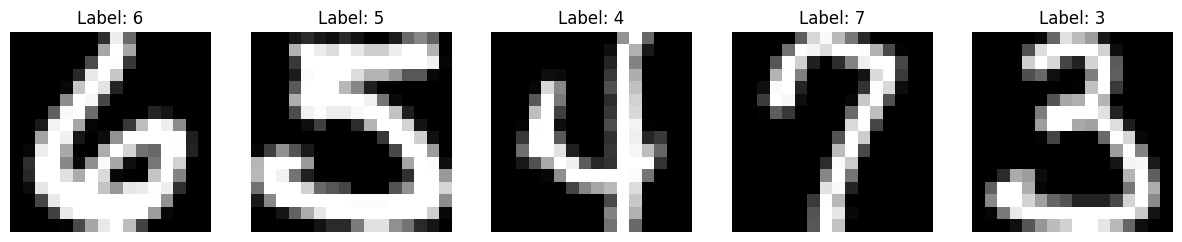

In [16]:
# Display 5 images in a row
plt.figure(figsize=(15, 5))
indices = [0, 1, 2, 3, 4]  # Example indices for the images to display

for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    img = X_tr[idx].reshape(16, 16)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_tr[idx]}")
    plt.axis('off')

plt.show()


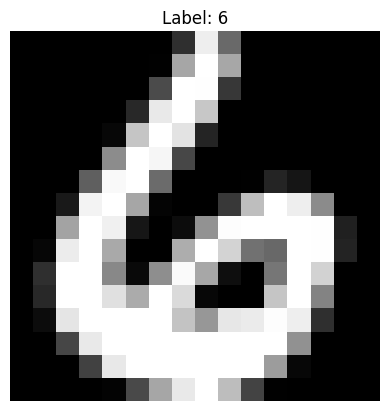

In [18]:
import matplotlib.pyplot as plt

# Index of the image you want to display (e.g., first image)
index = 0

# Reshape the image from 256 to 16x16
img = X_tr[index].reshape(16, 16)

# Display the image
plt.imshow(img, cmap='gray')  # 'cmap="gray"' is for grayscale images
plt.title(f"Label: {y_tr[index]}")
plt.axis('off')  # Hide the axes
plt.show()


In [53]:
import cv2
def extract_sift_features(images):
    sift = cv2.SIFT_create()
    feature_list = []

    for img in images:
        # Ensure the image is in grayscale
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Convert to uint8 if needed
        if img.dtype != np.uint8:
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        keypoints, descriptors = sift.detectAndCompute(img, None)
        if descriptors is None:
            descriptors = np.zeros((1, 128))  # Handle empty descriptor case

        feature_list.append(descriptors.flatten())

    return np.array(feature_list, dtype=object)


In [54]:
def evaluate_classifier(model, X, y, k_folds=10):
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    y_pred = cross_val_predict(model, X, y, cv=skf)
    conf_matrix = confusion_matrix(y, y_pred)
    class_report = classification_report(y, y_pred)
    return scores, conf_matrix, class_report


In [55]:
X_tr = extract_sift_features(X_tr)
X_te = extract_sift_features(X_te)

In [56]:
scaler = StandardScaler()
X_tr = scaler.fit_transform(np.vstack(X_tr))
X_te = scaler.fit_transform(np.vstack(X_te))

In [58]:
for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores, conf_matrix, class_report = evaluate_classifier(knn, X_tr, y_tr)
    print(f'kNN (k={k}) Accuracy: {np.mean(scores):.4f}')
    print(class_report)

kNN (k=1) Accuracy: 0.0897
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1194
           1       0.00      0.00      0.00      1005
           2       0.00      0.00      0.00       731
           3       0.00      0.00      0.00       658
           4       0.00      0.00      0.00       652
           5       0.08      0.10      0.09       556
           6       0.09      0.90      0.17       664
           7       0.00      0.00      0.00       645
           8       0.00      0.00      0.00       542
           9       0.00      0.00      0.00       644

    accuracy                           0.09      7291
   macro avg       0.02      0.10      0.03      7291
weighted avg       0.01      0.09      0.02      7291

kNN (k=3) Accuracy: 0.0894
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1194
           1       0.00      0.00      0.00      1005
           2       0.00 

In [60]:
nb = GaussianNB()
scores, conf_matrix, class_report = evaluate_classifier(nb, X_tr, y_tr)
print(f'Naive Bayes Accuracy: {np.mean(scores):.4f}')
print(class_report)


Naive Bayes Accuracy: 0.1638
              precision    recall  f1-score   support

           0       0.16      1.00      0.28      1194
           1       0.00      0.00      0.00      1005
           2       0.00      0.00      0.00       731
           3       0.00      0.00      0.00       658
           4       0.00      0.00      0.00       652
           5       0.00      0.00      0.00       556
           6       0.00      0.00      0.00       664
           7       0.00      0.00      0.00       645
           8       0.00      0.00      0.00       542
           9       0.00      0.00      0.00       644

    accuracy                           0.16      7291
   macro avg       0.02      0.10      0.03      7291
weighted avg       0.03      0.16      0.05      7291

